# Temporary signal-only diagnostics

Run all cells in a fresh kernel **before completing notebook 02**. Only the saved reference flow and signal-ratio ensemble are required. Keep the current TAG and run directory. This notebook never trains, renormalizes, selects members, or changes model files. Results go to `hybrid/signal_only_diagnostics/`.

We use one million fresh events per class (four times the previous diagnostic size), with fine bins around scores 0.70–0.85. Counts and approximate pointwise 95% intervals accompany the calibration curves. Exact-density comparisons test errors that can cancel inside calibration bins. Optional checkpoint comparisons investigate export or checkpoint-selection problems. Changing DIAGNOSTIC_SEED gives an independent repeat; finite-sample intervals do not include training uncertainty.


In [1]:
# Run this cell first in each notebook. All five notebooks share RUN_NAME.
import os
import sys
import subprocess
from pathlib import Path

TAG = "sb10_exppoly_10m_slowlr_v3_20261001"  # Fresh run: 10M nominal-ratio events per class and gradual LR decay.
RUN_NAME = TAG
USE_DRIVE = True
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    REPO = Path("/content/nsbi_calibration_toolkit")
    BRANCH = "ml4hep_school_tutorial"
    if not (REPO / ".git").exists():
        subprocess.run([
            "git", "clone", "--depth", "1", "--filter=blob:none", "--sparse",
            "--branch", BRANCH,
            "https://github.com/rafaellopesdesa/nsbi-lhc-toolkit.git", str(REPO),
        ], check=True, env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"})
        subprocess.run([
            "git", "-C", str(REPO), "sparse-checkout", "set", "src",
            "workshops/ml4hep_tifr_colab/calibration",
        ], check=True)
    else:
        subprocess.run(["git", "-C", str(REPO), "pull", "--ff-only", "origin", BRANCH], check=True)
    SOURCE = REPO / "workshops/ml4hep_tifr_colab/calibration"
    subprocess.run([
        sys.executable, "-m", "pip", "install", "-q", "-r",
        str(SOURCE / "requirements.txt"),
    ], check=True)
    if USE_DRIVE:
        from google.colab import drive
        drive.mount("/content/drive")
        RUN_BASE = Path("/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs")
    else:
        RUN_BASE = Path("/content/calibration_runs")
else:
    # Open the notebook with calibration/ as its working directory.
    SOURCE = Path.cwd().resolve()
    REPO = SOURCE.parents[2]
    RUN_BASE = SOURCE / "runs"

sys.path.insert(0, str(REPO / "src"))
sys.path.insert(0, str(SOURCE))
os.chdir(SOURCE)
RUN = Path(os.environ.get("CALIBRATION_RUN", RUN_BASE / RUN_NAME)).resolve()
RUN.mkdir(parents=True, exist_ok=True)
print("Source:", SOURCE)
print("TAG:", TAG)
print("Run:", RUN)
if "CALIBRATION_RUN" in os.environ:
    print("CALIBRATION_RUN overrides the tagged path; verify that it points to the intended run.")
print("Use a fresh kernel when switching between the old exercises and calibration.")


Mounted at /content/drive
Source: /content/nsbi_calibration_toolkit/workshops/ml4hep_tifr_colab/calibration
TAG: sb10_exppoly_10m_slowlr_v3_20261001
Run: /content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/sb10_exppoly_10m_slowlr_v3_20261001
Use a fresh kernel when switching between the old exercises and calibration.


In [2]:
import json
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from scipy.special import expit, logsumexp
from IPython.display import display
from flow_reference import ReferenceFlow
from utils import RatioEnsemble
from sampling import sample_process, process_log_density
from ratio_diagnostics import diagnostic_report

N_PER_CLASS = 1_000_000
DIAGNOSTIC_SEED = 5_100_503
CHECK_EXPORT = True
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
ROOT = RUN / 'hybrid'
SIGNAL = ROOT / 'ratios' / 'signal'
OUT = ROOT / 'signal_only_diagnostics' / f'seed_{DIAGNOSTIC_SEED}'
manifest = SIGNAL / 'ensemble.json'
if not manifest.is_file():
    raise FileNotFoundError(f'Completed signal ensemble required: {manifest}. No training started.')
metadata = json.loads(manifest.read_text())
members = metadata['members']
required = [ROOT / 'reference.pt']
for i in range(members):
    required += [SIGNAL / f'model{i}.onnx', SIGNAL / f'model_scaler{i}.bin']
missing = [str(p) for p in required if not p.is_file()]
if missing:
    raise FileNotFoundError('Missing saved files; no training started:\n' + '\n'.join(missing))
if N_PER_CLASS < 2:
    raise ValueError('Use at least two events per class.')
OUT.mkdir(parents=True, exist_ok=True)
flow = ReferenceFlow.load(ROOT / 'reference.pt', DEVICE)
ratio = RatioEnsemble.load(SIGNAL, device=DEVICE)
print('Saved ensemble metadata:')
display(metadata)
print('Diagnostic output:', OUT)


Saved ensemble metadata:


{'members': 4,
 'output': 'log_density_ratio',
 'seed': 13201,
 'n_numerator': 10000000,
 'n_denominator': 10000000,
 'settings': {'hidden_layers': 4,
  'neurons': 1024,
  'number_of_epochs': 150,
  'batch_size': 4096,
  'learning_rate': 0.001,
  'scalerType': 'MinMax',
  'holdout_split': 0.25,
  'validation_split': 0.2,
  'callback_patience': 10,
  'callback_factor': 0.5,
  'early_stopping_patience': 150,
  'num_workers': 0,
  'verbose': 1,
  'calibration': False}}

Diagnostic output: /content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/sb10_exppoly_10m_slowlr_v3_20261001/hybrid/signal_only_diagnostics/seed_5100503


,model,members,n_num,n_den,bce,bce_se,bce_excess_exact,bce_excess_exact_se,bce_excess_exact_low95,bce_excess_exact_high95,...,mean_log_error_num,mean_log_error_se_num,rms_log_error_num,tail_score_gt_075_num,tail_score_gt_090_num,mean_log_error_den,mean_log_error_se_den,rms_log_error_den,tail_score_gt_075_den,tail_score_gt_090_den
0,Member 1,1,1000000,1000000,0.631100,0.000216,0.001387,0.000037,0.001315,0.001459,...,-0.005287,0.000309,0.309056,0.001087,0.000753,-0.000512,0.000113,0.112529,0.000161,0.000024
1,Member 2,1,1000000,1000000,0.631070,0.000215,0.001356,0.000037,0.001285,0.001428,...,0.000115,0.000275,0.274637,0.001046,0.000673,0.011940,0.000112,0.112626,0.000142,0.000014
2,Member 3,1,1000000,1000000,0.631034,0.000217,0.001321,0.000036,0.001251,0.001391,...,0.013359,0.000309,0.309245,0.000940,0.000652,0.018200,0.000110,0.111509,0.000115,0.000010
3,Member 4,1,1000000,1000000,0.631067,0.000215,0.001354,0.000036,0.001283,0.001424,...,0.006275,0.000197,0.196906,0.000897,0.000628,0.018186,0.000110,0.111157,0.000096,0.000010
4,Ensemble,4,1000000,1000000,0.630896,0.000215,0.001183,0.000034,0.001117,0.001250,...,0.005871,0.000348,0.347662,0.001020,0.000725,0.012902,0.000103,0.104141,0.000129,0.000018
5,Exact ratio,0,1000000,1000000,0.629713,0.000217,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.001545,0.000872,0.000000,0.000000,0.000000,0.000175,0.000010


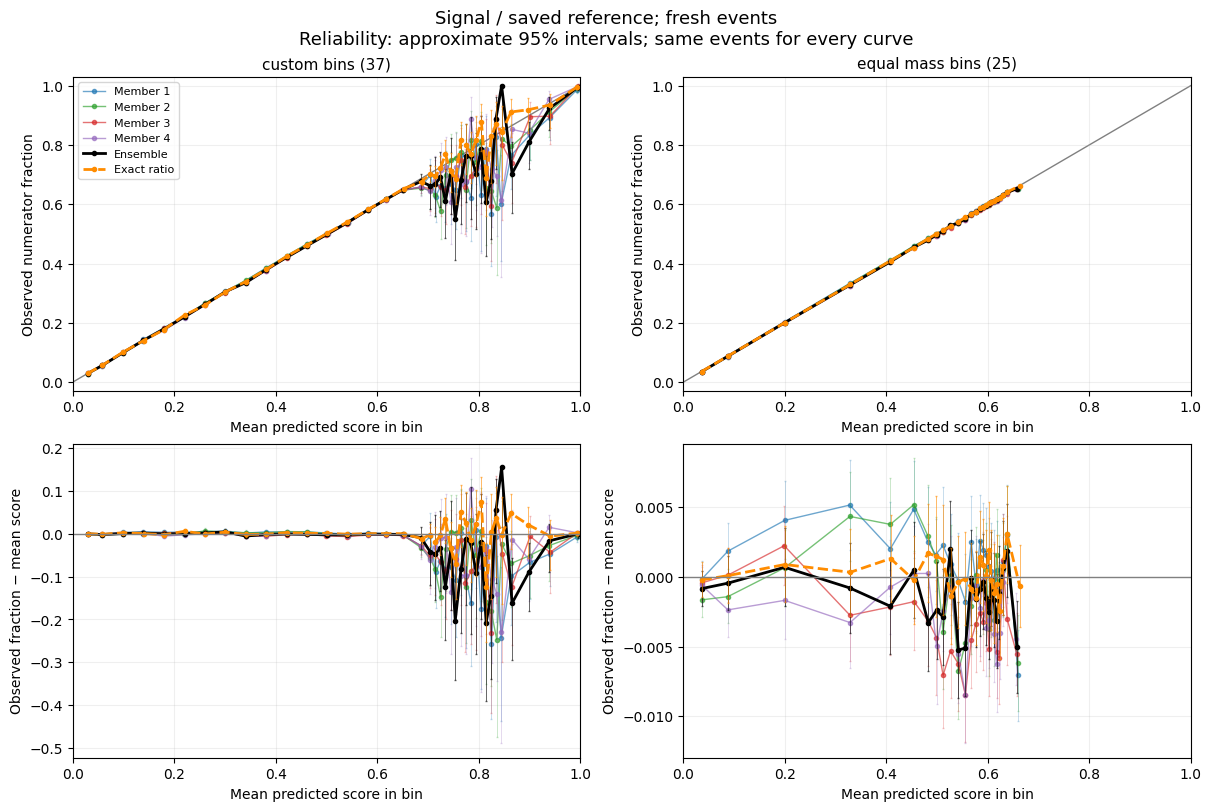

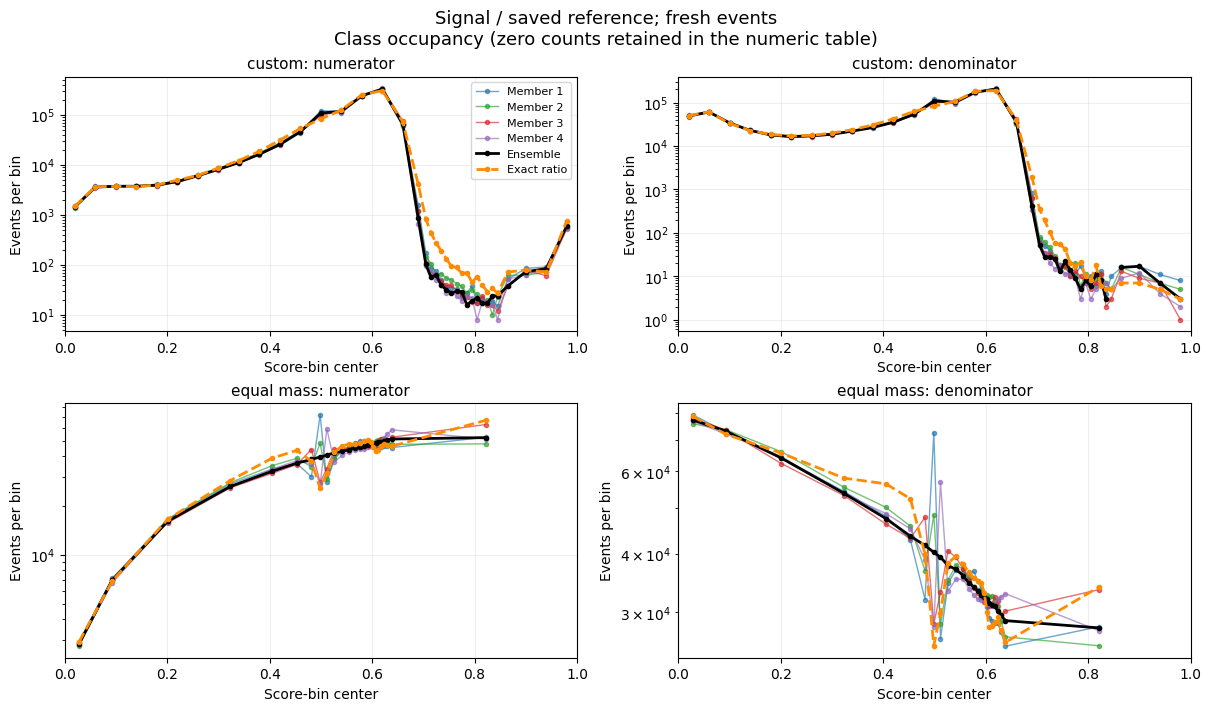

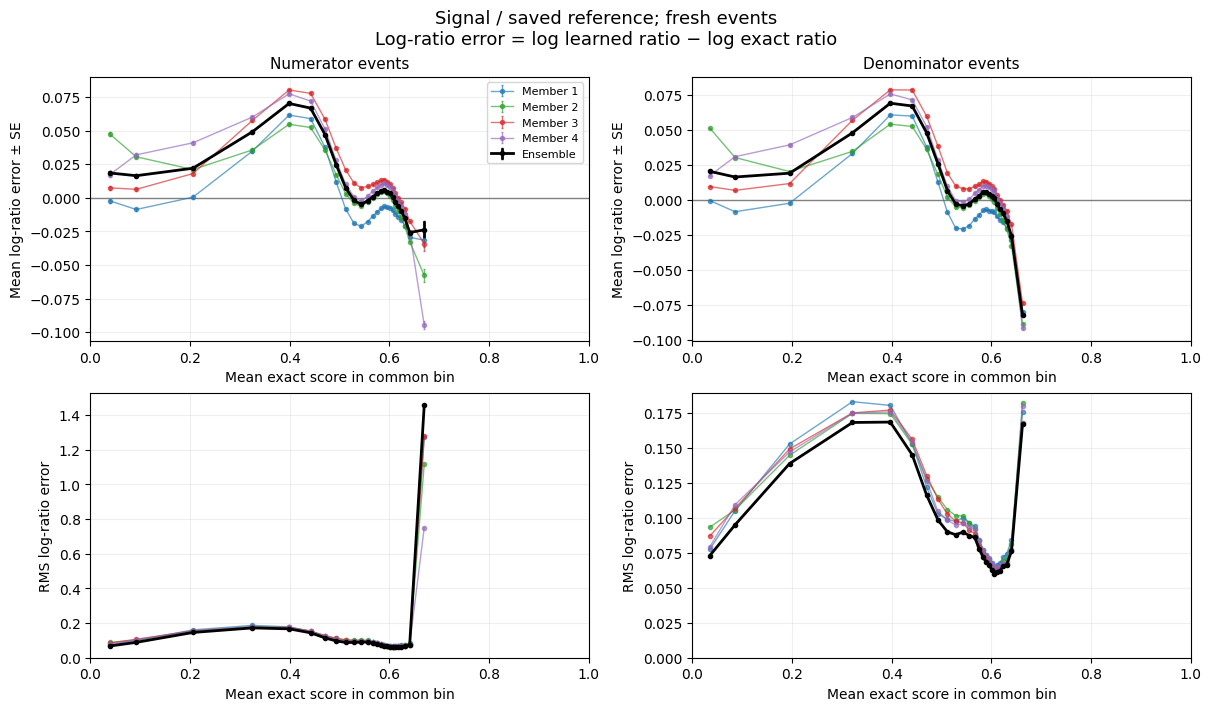

Ensemble = arithmetic mean of ratios, evaluated stably in log space.
Reliability bars are approximate pointwise Wilson 95% intervals for balanced samples.
CSV residual_delta_se additionally includes fluctuations of the bin mean score via a class-stratified delta method; sparse-bin estimates may degenerate.
Equal-mass reliability edges come from the pooled ensemble scores and are shared by all models.
Exact-error edges come from the pooled exact scores and are shared by all models.
BCE excess SE pairs each model with the exact oracle on the same events within each independent class.
Finite-bank normalization and ESS estimates do not measure training uncertainty.
No ranking, member selection, recalibration, or retraining is performed.


In [3]:
# Fresh independent banks: no sample parquet or background model is needed.
numerator = sample_process('signal', N_PER_CLASS, np.random.default_rng(DIAGNOSTIC_SEED))
denominator = flow.sample(N_PER_CLASS, DIAGNOSTIC_SEED + 1, batch_size=8192)
logq_n = flow.log_prob(numerator, batch_size=8192).astype(np.float64)
logq_d = flow.log_prob(denominator, batch_size=8192).astype(np.float64)
exact_n = process_log_density(numerator, 'signal') - logq_n
exact_d = process_log_density(denominator, 'signal') - logq_d
member_n = ratio.member_log_ratios(numerator)
member_d = ratio.member_log_ratios(denominator)
ensemble_n = logsumexp(member_n, axis=0) - np.log(members)
ensemble_d = logsumexp(member_d, axis=0) - np.log(members)
# Retain global coverage, adding narrow fixed bins in the region of concern.
score_edges = np.unique(np.round(np.r_[np.linspace(0, 1, 26), np.arange(.70, .851, .01)], 8))
report = diagnostic_report(member_n, member_d, exact_n, exact_d,
                           title='Signal / saved reference; fresh events',
                           score_edges=score_edges)
display(report['summary'])
report['summary'].to_csv(OUT / 'summary.csv', index=False)
report['bins'].to_csv(OUT / 'bins.csv', index=False)
for name, fig in report['figures']:
    fig.savefig(OUT / f'{name}.png', dpi=150, bbox_inches='tight')
    display(fig)
    plt.close(fig)
for note in report['notes']:
    print(note)


## Resolve the feature around 0.75

The table and zoom use each model's own predicted-score bins, with counts retained even for sparse bins. The black ensemble curve uses the arithmetic mean of ratios. The exact-ratio curve is a useful finite-sample control, but its bins contain different events. The following common-region table instead selects **the same events using the ensemble score** and compares all members there.


,model,score_left,score_right,n_num,n_den,score_mean,fraction_num,residual_low95,residual_high95
18,Member 1,0.70,0.71,169.0,73.0,0.704559,0.698347,-0.066768,0.048146
19,Member 1,0.71,0.72,85.0,51.0,0.715061,0.625000,-0.173807,-0.013182
20,Member 1,0.72,0.73,76.0,39.0,0.724767,0.660870,-0.154371,0.016176
21,Member 1,0.73,0.74,49.0,26.0,0.734636,0.653333,-0.194089,0.016541
22,Member 1,0.74,0.75,36.0,18.0,0.745031,0.666667,-0.211421,0.032555
...,...,...,...,...,...,...,...,...,...
588,Exact ratio,0.80,0.81,58.0,8.0,0.805260,0.878788,-0.026634,0.132022
589,Exact ratio,0.81,0.82,40.0,18.0,0.814978,0.689655,-0.253009,-0.021199
590,Exact ratio,0.82,0.83,29.0,6.0,0.825226,0.828571,-0.152049,0.093747
591,Exact ratio,0.83,0.84,34.0,5.0,0.834688,0.871795,-0.101745,0.109284


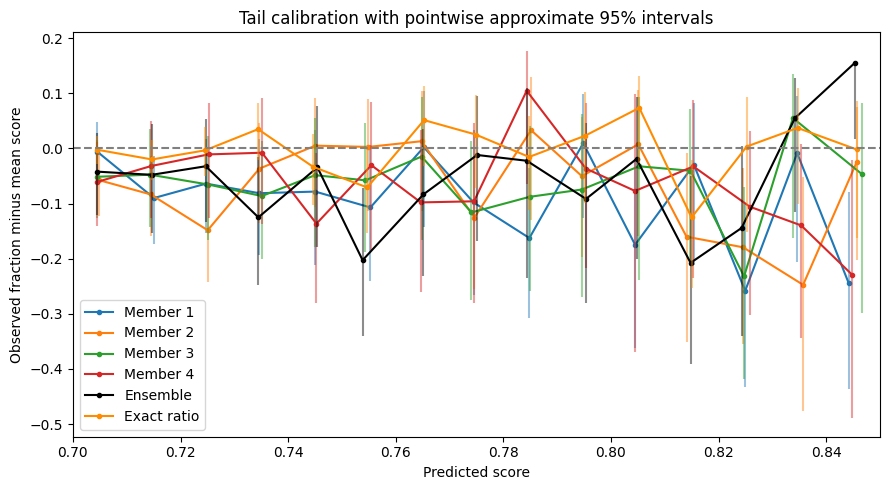

,region,sample,model,count,fraction,mean_log_error,mean_log_error_SE,RMS_log_error,mean_exact_probability_minus_score
0,"[0.70, 0.75)",numerator,Member 1,292,0.000292,-0.088439,0.060131,1.029568,-0.010838
1,"[0.70, 0.75)",numerator,Member 2,292,0.000292,-0.086918,0.059182,1.013307,-0.010923
2,"[0.70, 0.75)",numerator,Member 3,292,0.000292,-0.179233,0.059463,1.030070,0.006490
3,"[0.70, 0.75)",numerator,Member 4,292,0.000292,-0.243852,0.061172,1.071635,0.019737
4,"[0.70, 0.75)",numerator,Ensemble,292,0.000292,-0.107348,0.056666,0.972586,-0.010950
5,"[0.70, 0.75)",denominator,Member 1,146,0.000146,0.481339,0.061059,0.878790,-0.108905
6,"[0.70, 0.75)",denominator,Member 2,146,0.000146,0.464141,0.056210,0.820712,-0.104609
7,"[0.70, 0.75)",denominator,Member 3,146,0.000146,0.398553,0.053654,0.759117,-0.092473
8,"[0.70, 0.75)",denominator,Member 4,146,0.000146,0.346486,0.055496,0.752747,-0.080997
9,"[0.70, 0.75)",denominator,Ensemble,146,0.000146,0.470755,0.052610,0.789265,-0.110477


In [4]:
bins = report['bins']
focus = bins[(bins.diagnostic == 'calibration') & (bins.view == 'custom')
             & (bins.score_left >= .70) & (bins.score_right <= .85)]
display(focus[['model', 'score_left', 'score_right', 'n_num', 'n_den',
               'score_mean', 'fraction_num', 'residual_low95', 'residual_high95']])
fig, ax = plt.subplots(figsize=(9, 5))
for name, table in focus.groupby('model', sort=False):
    table = table[table.n_total > 0]
    color = 'black' if name == 'Ensemble' else 'darkorange' if name == 'Exact ratio' else None
    line, = ax.plot(table.score_mean, table.calibration_residual, '.-', label=name, color=color)
    ax.vlines(table.score_mean, table.residual_low95, table.residual_high95,
              color=line.get_color(), alpha=.45)
ax.axhline(0, color='grey', ls='--')
ax.set(xlim=(.70, .85), xlabel='Predicted score', ylabel='Observed fraction minus mean score',
       title='Tail calibration with pointwise approximate 95% intervals')
ax.legend()
fig.tight_layout()
fig.savefig(OUT / 'tail_zoom.png', dpi=150)
plt.show()
plt.close(fig)

# Same events for every model; distinguish mean bias from event-to-event error.
regions = [(.70, .75), (.75, .80), (.80, .85), (.85, 1.000001)]
models = [(f'Member {i+1}', member_n[i], member_d[i]) for i in range(members)]
models += [('Ensemble', ensemble_n, ensemble_d)]
rows = []
for lo, hi in regions:
    for label, selector, truth in [('numerator', ensemble_n, exact_n),
                                    ('denominator', ensemble_d, exact_d)]:
        mask = (expit(selector) >= lo) & (expit(selector) < hi)
        for name, ln, ld in models:
            values = (ln if label == 'numerator' else ld)[mask]
            error = values - truth[mask]
            oracle_residual = expit(truth[mask]) - expit(values)
            rows.append(dict(region=f'[{lo:.2f}, {min(hi,1):.2f})', sample=label, model=name,
                count=int(mask.sum()), fraction=mask.mean(),
                mean_log_error=error.mean() if len(error) else np.nan,
                mean_log_error_SE=error.std(ddof=1)/np.sqrt(len(error)) if len(error)>1 else np.nan,
                RMS_log_error=np.sqrt(np.mean(error**2)) if len(error) else np.nan,
                mean_exact_probability_minus_score=oracle_residual.mean() if len(error) else np.nan))
common_regions = pd.DataFrame(rows)
common_regions.to_csv(OUT / 'common_tail_regions.csv', index=False)
display(common_regions)


## Check ensemble sensitivity and extreme weights

Leave-one-member-out comparisons are exploratory; no member is removed from the saved ensemble. The normalization and weight-concentration summaries reveal whether a small number of reference events dominate the arithmetic mean. The event table lists the 30 largest ensemble weights on the fresh denominator bank for inspection, including each member's log ratio and the exact value.


In [5]:
variants = models + [('Exact ratio', exact_n, exact_d)]
if members > 1:
    for i in range(members):
        keep = np.arange(members) != i
        variants.append((f'Without member {i+1}',
                         logsumexp(member_n[keep], axis=0)-np.log(members-1),
                         logsumexp(member_d[keep], axis=0)-np.log(members-1)))
baseline_n, baseline_d = np.logaddexp(0., -ensemble_n), np.logaddexp(0., ensemble_d)
sensitivity = []
for name, ln, ld in variants:
    loss_n, loss_d = np.logaddexp(0., -ln), np.logaddexp(0., ld)
    dn, dd = loss_n-baseline_n, loss_d-baseline_d
    scaled = np.exp(ld-ld.max())
    order = np.sort(scaled)[::-1]
    log_mean = logsumexp(ld)-np.log(len(ld))
    with np.errstate(over='ignore'):
        mean_ratio = np.exp(log_mean)
    sensitivity.append(dict(model=name, BCE=.5*(loss_n.mean()+loss_d.mean()),
        BCE_minus_ensemble=.5*(dn.mean()+dd.mean()),
        paired_difference_SE=.5*np.sqrt(dn.var(ddof=1)/len(dn)+dd.var(ddof=1)/len(dd)),
        mean_ratio_den=mean_ratio, log_mean_ratio_den=log_mean,
        ESS=scaled.sum()**2/np.square(scaled).sum(),
        top1_weight_fraction=order[:1].sum()/order.sum(),
        top10_weight_fraction=order[:10].sum()/order.sum(),
        top100_weight_fraction=order[:100].sum()/order.sum()))
sensitivity = pd.DataFrame(sensitivity)
sensitivity.to_csv(OUT / 'ensemble_sensitivity.csv', index=False)
display(sensitivity)
idx = np.argsort(ensemble_d)[-30:][::-1]
outliers = pd.DataFrame(denominator[idx], columns=[f'x{i+1}' for i in range(5)])
outliers['log_q'] = logq_d[idx]
outliers['exact_log_ratio'] = exact_d[idx]
outliers['ensemble_log_ratio'] = ensemble_d[idx]
for i in range(members):
    outliers[f'member_{i+1}_log_ratio'] = member_d[i, idx]
outliers['largest_member_fraction_of_ratio_sum'] = np.exp(
    member_d[:, idx].max(axis=0)-logsumexp(member_d[:, idx], axis=0))
outliers.to_csv(OUT / 'largest_denominator_weights.csv', index=False)
display(outliers)


,model,BCE,BCE_minus_ensemble,paired_difference_SE,mean_ratio_den,log_mean_ratio_den,ESS,top1_weight_fraction,top10_weight_fraction,top100_weight_fraction
0,Member 1,0.631100,0.000204,0.000014,0.996588,-0.003418,732113.807854,0.000151,0.000480,0.001086
1,Member 2,0.631070,0.000173,0.000014,1.003256,0.003251,585371.508785,0.000587,0.000978,0.001461
2,Member 3,0.631034,0.000137,0.000013,1.015244,0.015129,711254.280625,0.000284,0.000417,0.000826
3,Member 4,0.631067,0.000170,0.000013,1.010260,0.010208,754332.389446,0.000036,0.000170,0.000570
4,Ensemble,0.630896,0.000000,0.000000,1.006337,0.006317,720643.612992,0.000243,0.000435,0.000910
5,Exact ratio,0.629713,-0.001183,0.000034,0.998762,-0.001239,744678.872043,0.000060,0.000241,0.000652
6,Without member 1,0.630910,0.000014,0.000005,1.009587,0.009541,706350.815606,0.000297,0.000466,0.000881
7,Without member 2,0.630914,0.000018,0.000005,1.007364,0.007337,743728.419518,0.000129,0.000307,0.000771
8,Without member 3,0.630927,0.000030,0.000004,1.003368,0.003362,721828.583490,0.000229,0.000475,0.000975
9,Without member 4,0.630911,0.000015,0.000004,1.005029,0.005017,697785.462649,0.000317,0.000547,0.001054


,x1,x2,x3,x4,x5,log_q,exact_log_ratio,ensemble_log_ratio,member_1_log_ratio,member_2_log_ratio,member_3_log_ratio,member_4_log_ratio,largest_member_fraction_of_ratio_sum
0,-7.019514,1.340993,0.404365,-2.408692,10.909201,-23.278465,-0.002612,5.499041,4.346669,6.378467,5.664922,3.136361,0.602379
1,3.555997,-0.320183,13.223610,6.943528,-1.136990,-23.734310,1.277847,3.860927,1.001182,5.188886,0.989626,1.678397,0.943334
2,12.908813,-5.931979,4.177763,6.028008,1.337559,-21.074596,-1.488356,3.690341,5.016162,1.675055,0.407152,0.940392,0.941320
3,-0.285997,7.089553,-3.714863,-5.657615,9.817202,-23.863148,-0.551859,2.920732,1.392434,4.226513,-0.068126,-0.245086,0.922643
4,2.954504,-6.088752,1.664680,2.142656,-0.447695,-19.841547,2.875439,2.880479,3.169663,1.802538,1.520164,3.606958,0.516947
5,4.375401,-2.442988,-0.472788,-7.378736,1.963271,-19.797626,0.525923,2.791481,2.984639,3.066552,1.750223,2.902387,0.329156
6,1.247678,3.762434,-0.067603,11.068943,8.630714,-22.897335,1.176770,2.705498,3.752516,2.397547,1.225402,1.035717,0.712286
7,7.020538,4.385565,7.443217,-7.445363,4.585574,-21.567055,1.805231,2.618930,3.404860,1.928888,0.968280,2.725156,0.548612
8,-2.430600,1.833790,3.022542,7.331589,-5.102061,-20.677399,0.982027,2.520656,3.610076,1.048856,1.980026,0.986126,0.743137
9,9.997092,-5.606022,4.342229,0.469159,-4.157663,-22.298296,0.604222,2.488190,3.330873,0.576175,2.782738,0.812117,0.580648


## Optional checkpoint/export audit

The existing trainer shares a checkpoint directory among members, so filenames alone do not identify the member. Compare each checkpoint with each exported member using that member's saved scaler. A matching pair should have small floating-point differences. A missing match can also mean the corresponding checkpoint was removed; it is not by itself evidence of a faulty export. Saved epoch numbers use Lightning's zero-based convention. Only load checkpoints produced by your own run.


In [6]:
if CHECK_EXPORT:
    from nsbi_common_utils.lightning_tools import DensityRatioLightning
    paths = sorted((SIGNAL / 'checkpoints').glob('*.ckpt'))
    # Include independent bulk events and the high-weight reference events.
    probe = np.concatenate([numerator[:128], denominator[:128], denominator[idx]])
    exported = ratio.member_log_ratios(probe)
    audit, failures = [], []
    for path in paths:
        try:
            saved = torch.load(path, map_location='cpu', weights_only=False)
            epoch = saved.get('epoch')
            params = saved.get('hyper_parameters', {})
            checkpoint = DensityRatioLightning.load_from_checkpoint(path, map_location='cpu').eval()
            for i, (scaler, _) in enumerate(ratio.members):
                scaled_probe = scaler.transform(pd.DataFrame(probe, columns=[f'x{j+1}' for j in range(5)]))
                with torch.no_grad():
                    predicted = checkpoint(torch.as_tensor(np.asarray(scaled_probe), dtype=torch.float32)).numpy().reshape(-1)
                error = predicted-exported[i]
                audit.append(dict(checkpoint=path.name, epoch=epoch, exported_member=i+1,
                    max_abs_logit_difference=np.max(np.abs(error)),
                    RMS_logit_difference=np.sqrt(np.mean(error**2)),
                    initial_lr=params.get('learning_rate'),
                    decay_factor=params.get('callback_factor'),
                    decay_interval=params.get('callback_patience')))
            del checkpoint, saved
        except Exception as exc:
            failures.append(dict(checkpoint=path.name, error=str(exc)))
    if audit:
        audit = pd.DataFrame(audit)
        audit.to_csv(OUT / 'checkpoint_export_audit.csv', index=False)
        display(audit)
        print('Closest checkpoint for each exported member (diagnostic only):')
        display(audit.loc[audit.groupby('exported_member').RMS_logit_difference.idxmin()])
    else:
        print('No comparable checkpoints available; ONNX diagnostics above remain usable.')
    if failures:
        display(pd.DataFrame(failures))
        pd.DataFrame(failures).to_csv(OUT / 'checkpoint_audit_failures.csv', index=False)

(OUT / 'settings.json').write_text(json.dumps(dict(
    tag=TAG, run=str(RUN), seed=DIAGNOSTIC_SEED, n_per_class=N_PER_CLASS,
    ensemble_metadata=metadata, checkpoint_audit=CHECK_EXPORT,
    note='Read-only signal diagnostic; no training, normalization, or member selection.'), indent=2))
print('Finished. Commit this notebook with its outputs so we can inspect the result.')


,checkpoint,epoch,exported_member,max_abs_logit_difference,RMS_logit_difference,initial_lr,decay_factor,decay_interval
0,best-epoch=021-val_loss=0.630850_signalvsdenom...,21,1,4.608797,0.532117,0.001,0.5,10
1,best-epoch=021-val_loss=0.630850_signalvsdenom...,21,2,4.294574,0.583638,0.001,0.5,10
2,best-epoch=021-val_loss=0.630850_signalvsdenom...,21,3,0.005188,0.000442,0.001,0.5,10
3,best-epoch=021-val_loss=0.630850_signalvsdenom...,21,4,3.240469,0.465210,0.001,0.5,10
4,best-epoch=021-val_loss=0.630850_signalvsdenom...,21,1,4.608797,0.532117,0.001,0.5,10
5,best-epoch=021-val_loss=0.630850_signalvsdenom...,21,2,4.294574,0.583638,0.001,0.5,10
6,best-epoch=021-val_loss=0.630850_signalvsdenom...,21,3,0.005188,0.000442,0.001,0.5,10
7,best-epoch=021-val_loss=0.630850_signalvsdenom...,21,4,3.240469,0.465210,0.001,0.5,10
8,best-epoch=021-val_loss=0.630934_signalvsdenom...,21,1,4.074791,0.563119,0.001,0.5,10
9,best-epoch=021-val_loss=0.630934_signalvsdenom...,21,2,4.471429,0.630554,0.001,0.5,10


Closest checkpoint for each exported member (diagnostic only):


,checkpoint,epoch,exported_member,max_abs_logit_difference,RMS_logit_difference,initial_lr,decay_factor,decay_interval
16,best-epoch=031-val_loss=0.630971_signalvsdenom...,31,1,0.004375,0.000596,0.001,0.5,10
13,best-epoch=029-val_loss=0.630751_signalvsdenom...,29,2,0.006982,0.000762,0.001,0.5,10
2,best-epoch=021-val_loss=0.630850_signalvsdenom...,21,3,0.005188,0.000442,0.001,0.5,10
11,best-epoch=021-val_loss=0.630934_signalvsdenom...,21,4,0.003142,0.000384,0.001,0.5,10


Finished. Commit this notebook with its outputs so we can inspect the result.
